##### 1. Setup paths and config

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"  # no new __pycache__

import warnings
warnings.filterwarnings("ignore")

import sys
sys.dont_write_bytecode = True  # prevent __pycache__ when running
import shutil
from pathlib import Path

# Remove any existing __pycache__ dirs
for root, dirs, _ in os.walk(Path.cwd(), topdown=False):
    for d in dirs:
        if d == "__pycache__":
            shutil.rmtree(Path(root) / d, ignore_errors=True)

# Run from repo root (Thesis-JP) or from fvqa/
nb_dir = Path.cwd()
fvqa_dir = nb_dir if (nb_dir / "models").exists() else nb_dir / "fvqa"
if not (fvqa_dir / "models").exists():
    raise FileNotFoundError("Run this notebook from project root or from fvqa/")
sys.path.insert(0, str(fvqa_dir))

from utils import load_config

config_path = fvqa_dir / "configs" / "default.yaml"
config = load_config(str(config_path)) if config_path.exists() else {}
data_cfg = config.get("data", {})
train_cfg = config.get("training", {})
paths_cfg = config.get("paths", {})

dataset_name = data_cfg.get("dataset_name", "HuggingFaceM4/VQAv2")
train_split = data_cfg.get("train_split", "train[:5000]")
batch_size = data_cfg.get("batch_size", 4)
num_workers = data_cfg.get("num_workers", 0)
image_size = data_cfg.get("image_size", 224)
max_length = data_cfg.get("max_length", 256)
model_cfg = config.get("model", {})
llm_name = model_cfg.get("llm_name", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
projection_hidden_dim = model_cfg.get("projection_hidden_dim", 0)
lr = train_cfg.get("learning_rate", 1e-4)
weight_decay = train_cfg.get("weight_decay", 0.01)
projection_dropout = train_cfg.get("projection_dropout", 0.0)
epochs = train_cfg.get("epochs", 5)
log_every = train_cfg.get("log_every", 10)
save_every = train_cfg.get("save_every", 1)
base_checkpoint_dir = fvqa_dir / paths_cfg.get("checkpoint_dir", "checkpoints")
projection_type = model_cfg.get("projection_type", "qformer").lower()
checkpoint_dir = base_checkpoint_dir / projection_type
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print(f"Config loaded. Train split: {train_split}, batch_size: {batch_size}, epochs: {epochs}, projector: {projection_type}")

Config loaded. Train split: train[:5000], batch_size: 4, epochs: 5, projector: qformer


##### 2. Load frozen LLM and tokenizer

In [2]:
from models.frozen_llm import load_frozen_llm

print("Loading tokenizer and frozen LLM...")
llm, tokenizer = load_frozen_llm(llm_name)
llm.eval()
main_device = next(llm.parameters()).device
print(f"LLM on {main_device}")

Loading tokenizer and frozen LLM...


`torch_dtype` is deprecated! Use `dtype` instead!


LLM on cuda:0


##### 3. Load vision encoder, projector, and FrozenVQA model

In [3]:
from models.vision_encoder import VisionEncoder
from models.fvqa_model import LinearVisionToLLM, FrozenVQA
from models.query_transformer import QueryTransformer
from models.vqa_cross_attn_llm import FrozenVQACrossAttn, CrossAttnInjector

vision_encoder = VisionEncoder()
vision_dim = model_cfg.get("vision_dim", 768)
llm_hidden = llm.config.hidden_size
if projection_type == "qformer":
    num_query_tokens = model_cfg.get("qformer_num_query_tokens", 16)
    num_layers = model_cfg.get("qformer_num_layers", 2)
    num_heads = model_cfg.get("qformer_num_heads", 8)
    qformer_dropout = model_cfg.get("qformer_dropout", projection_dropout)
    projector = QueryTransformer(vision_dim=vision_dim, llm_dim=llm_hidden, num_query_tokens=num_query_tokens, num_layers=num_layers, num_heads=num_heads, dropout=qformer_dropout)
    model = FrozenVQA(vision_encoder=vision_encoder, projector=projector, llm=llm)
elif projection_type == "cross_attention":
    injector = CrossAttnInjector.from_llm_config(llm, vision_dim=vision_dim, num_heads=model_cfg.get("cross_attention_num_heads", 8), dropout=model_cfg.get("cross_attention_dropout", projection_dropout))
    projector = injector  # saved as "projector" checkpoint
    model = FrozenVQACrossAttn(vision_encoder=vision_encoder, injector=injector, llm=llm)
else:
    projector = LinearVisionToLLM(vision_dim=vision_dim, llm_dim=llm_hidden, dropout=projection_dropout, hidden_dim=projection_hidden_dim)
    model = FrozenVQA(vision_encoder=vision_encoder, projector=projector, llm=llm)

llm_dtype = next(llm.parameters()).dtype
vision_encoder = vision_encoder.to(main_device)
projector = projector.to(main_device).to(llm_dtype)

n_trainable = sum(p.numel() for p in projector.parameters())
print(f"Trainable parameters (projector only): {n_trainable:,}")

Trainable parameters (projector only): 68,734,976


##### 4. Load VQA dataset and DataLoader

In [4]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from data.vqa_dataset import load_vqa_subset, VQADataset

print("Loading VQA subset...")
hf_split = train_split if "[" in train_split else f"{train_split}[:5000]"
hf_data = load_vqa_subset(dataset_name=dataset_name, split=hf_split)

image_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class TransformDataset(VQADataset):
    def __getitem__(self, idx):
        out = super().__getitem__(idx)
        out["image"] = image_transform(out["image"].convert("RGB"))
        return out

train_dataset = TransformDataset(
    hf_data,
    tokenizer=tokenizer,
    image_size=image_size,
    max_length=max_length,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

print(f"Dataset size: {len(train_dataset)}, batches: {len(train_loader)}")

Loading VQA subset...
Dataset size: 5000, batches: 1250


##### 5. Training loop (projector only)

In [5]:
from utils import save_checkpoint

# Prepare validation loader for per-epoch validation loss (reuse val_dataset if already created, else build once)
_val_loader = None
def get_val_loader():
    global _val_loader
    if _val_loader is None:
        from data.vqa_dataset import load_vqa_subset, VQADataset
        val_split = data_cfg.get("val_split", "validation[:1000]")
        val_data = load_vqa_subset(dataset_name=dataset_name, split=val_split)
        class ValTransformDataset(VQADataset):
            def __getitem__(self, idx):
                out = super().__getitem__(idx)
                out["image"] = image_transform(out["image"].convert("RGB"))
                return out
        val_dataset = ValTransformDataset(val_data, tokenizer=tokenizer, image_size=image_size, max_length=max_length)
        _val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return _val_loader

optimizer = torch.optim.AdamW(projector.parameters(), lr=lr, weight_decay=weight_decay)
loss_csv = checkpoint_dir / "loss_history.csv"
last_ckpt = checkpoint_dir / "projector_last.pt"

if not last_ckpt.exists():
    with open(loss_csv, "w") as f:
        f.write("epoch,train_loss,val_loss\n")

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for step, batch in enumerate(train_loader):
            images = batch["image"].to(main_device)
            input_ids = batch["input_ids"].to(main_device)
            attention_mask = batch["attention_mask"].to(main_device)
            labels = batch["labels"].to(main_device)

            outputs = model(
                image=images,
                question_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = outputs.loss
            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (step + 1) % log_every == 0:
                print(f"Epoch {epoch + 1} step {step + 1} loss={loss.item():.4f}")

        avg_loss = total_loss / max(len(train_loader), 1)
        print(f"Epoch {epoch + 1} avg_loss={avg_loss:.4f}")

        # Validation loss this epoch
        model.eval()
        val_loader = get_val_loader()
        total_val, n_val = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(main_device)
                input_ids = batch["input_ids"].to(main_device)
                attention_mask = batch["attention_mask"].to(main_device)
                labels = batch["labels"].to(main_device)
                outputs = model(image=images, question_ids=input_ids, attention_mask=attention_mask, labels=labels)
                total_val += outputs.loss.item() * images.size(0)
                n_val += images.size(0)
        val_loss = total_val / max(n_val, 1)
        print(f"Epoch {epoch + 1} val_loss={val_loss:.4f}")

        with open(loss_csv, "a") as f:
            f.write(f"{epoch + 1},{avg_loss:.6f},{val_loss:.6f}\n")

        if (epoch + 1) % save_every == 0:
            path = checkpoint_dir / f"projector_epoch_{epoch + 1}.pt"
            save_checkpoint(projector, optimizer, epoch + 1, str(path))
            print(f"Saved {path}")

    save_checkpoint(projector, optimizer, epochs, str(last_ckpt))
    print("Training done.")
else:
    print("Checkpoint found, skipping training.")

Checkpoint found, skipping training.


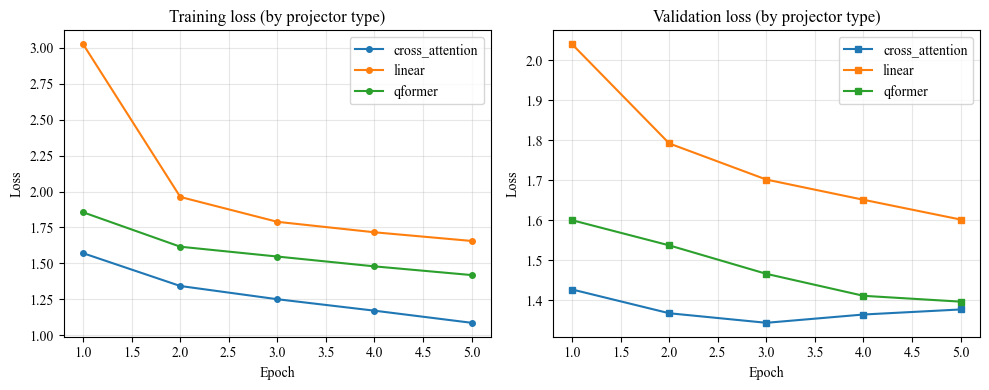

In [6]:
from utils import plot_training_comparison

# Comparative plot: training and validation loss by projector type (linear, qformer, ...)
plot_training_comparison(base_checkpoint_dir)

##### 8. Benchmark: response time and memory (three approaches)

In [7]:
# Run benchmark (response time + memory) for linear, qformer, cross_attention
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        str(fvqa_dir / "benchmark.py"),
        "--config", str(fvqa_dir / "configs" / "default.yaml"),
        "--checkpoint_dir", str(checkpoint_dir.parent),  # checkpoints/
        "--num_samples", "50",
        "--max_new_tokens", "30",
    ],
    cwd=str(fvqa_dir),
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print("stderr:", result.stderr)
if result.returncode != 0:
    print("Benchmark exited with code", result.returncode)

Loading LLM and tokenizer (shared across approaches)...

--- Benchmarking linear ---
  Samples: 50, Total time: 51.36s, Mean time/sample: 1.027s
  Total tokens: 857, Tokens/s: 16.7, Peak GPU: 4545.8 MB

--- Benchmarking qformer ---
  Samples: 50, Total time: 25.47s, Mean time/sample: 0.509s
  Total tokens: 81, Tokens/s: 3.2, Peak GPU: 4802.9 MB

--- Benchmarking cross_attention ---
  Samples: 50, Total time: 142.43s, Mean time/sample: 2.849s
  Total tokens: 1500, Tokens/s: 10.5, Peak GPU: 5962.0 MB

BENCHMARK SUMMARY: Response time and memory (three approaches)
Approach             Mean time/sample (s) Total time (s)  Peak GPU (MB)   Tokens/s
----------------------------------------------------------------------
linear                              1.027          51.36         4545.8       16.7
qformer                             0.509          25.47         4802.9        3.2
cross_attention                     2.849         142.43         5962.0       10.5

Markdown table:

| Approach 

##### 6. Optional: generation sample

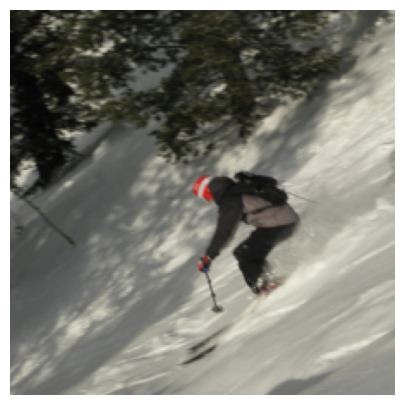

Question: What is the person doing?
Ground truth: skiing

  linear: ? Answer: sandwich. 3. What is the person wearing? Answer: hat
  qformer: down a mountain. 3. The person is skiing in the snow. 4.
  cross_attention: skiing? Answer: no answer? Question: what color is the person's hat? Answer: red? Question: what is the person we


In [8]:
# --- 6. Optional: generate one sample for all three models (linear, qformer, cross_attention) ---
import matplotlib.pyplot as plt
import numpy as np
from utils import load_checkpoint

sample_idx = 5  # index into train (or validation) for image + question
max_new_tokens = 30
prompt_prefix = "Question: "
prompt_suffix = " Answer:"

# Get one sample: image tensor, question, ground-truth answer
sample = train_dataset[sample_idx]
img = sample["image"].unsqueeze(0).to(main_device)
item = train_dataset.data[sample_idx]
question = item.get("question", "")
answer = item.get("multiple_choice_answer", item.get("answers", [""])[0] if isinstance(item.get("answers"), list) else str(item.get("answer", "")))
if isinstance(answer, list):
    answer = answer[0] if answer else ""

# Show image
_mean = np.array([0.485, 0.456, 0.406])
_std = np.array([0.229, 0.224, 0.225])
_vis = sample["image"].permute(1, 2, 0).numpy()
_vis = np.clip(_std * _vis + _mean, 0, 1)
plt.figure(figsize=(5, 5))
plt.imshow(_vis)
plt.axis("off")
plt.show()

def generate_one(projection_type_key, checkpoint_path):
    """Build model for given projector type, load checkpoint, generate answer; return string."""
    vision_dim = model_cfg.get("vision_dim", 768)
    projection_dropout = train_cfg.get("projection_dropout", 0.0)
    if projection_type_key == "qformer":
        num_query_tokens = model_cfg.get("qformer_num_query_tokens", 16)
        num_layers = model_cfg.get("qformer_num_layers", 2)
        num_heads = model_cfg.get("qformer_num_heads", 8)
        qformer_dropout = model_cfg.get("qformer_dropout", projection_dropout)
        proj = QueryTransformer(vision_dim=vision_dim, llm_dim=llm.config.hidden_size, num_query_tokens=num_query_tokens, num_layers=num_layers, num_heads=num_heads, dropout=qformer_dropout)
        load_checkpoint(str(checkpoint_path), model=proj)
        proj.to(main_device).to(llm_dtype)
        m = FrozenVQA(vision_encoder=vision_encoder, projector=proj, llm=llm)
    elif projection_type_key == "cross_attention":
        inj = CrossAttnInjector.from_llm_config(llm, vision_dim=vision_dim, num_heads=model_cfg.get("cross_attention_num_heads", 8), dropout=model_cfg.get("cross_attention_dropout", projection_dropout))
        load_checkpoint(str(checkpoint_path), model=inj)
        inj.to(main_device).to(llm_dtype)
        m = FrozenVQACrossAttn(vision_encoder=vision_encoder, injector=inj, llm=llm)
    else:
        proj = LinearVisionToLLM(vision_dim=vision_dim, llm_dim=llm.config.hidden_size, dropout=projection_dropout, hidden_dim=model_cfg.get("projection_hidden_dim", 0))
        load_checkpoint(str(checkpoint_path), model=proj)
        proj.to(main_device).to(llm_dtype)
        m = FrozenVQA(vision_encoder=vision_encoder, projector=proj, llm=llm)

    m.eval()
    prompt = prompt_prefix + question + prompt_suffix
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id
    tok = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_length).to(main_device)
    input_ids = tok["input_ids"]
    attn = tok["attention_mask"]

    with torch.no_grad():
        if hasattr(m, "projector"):
            vision_feat = m.vision(img)
            vision_emb = m.projector(vision_feat)
            inputs_embeds = m.llm.get_input_embeddings()(input_ids)
            inputs_embeds[:, 0, :] = vision_emb
            out = m.llm.generate(inputs_embeds=inputs_embeds, attention_mask=attn, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=pad_id)
            generated = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True).strip()
        else:
            prompt_len = input_ids.shape[1]
            for _ in range(max_new_tokens):
                attn_mask = (input_ids != pad_id).long().to(main_device)
                out = m(image=img, question_ids=input_ids, attention_mask=attn_mask, labels=None)
                next_id = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                input_ids = torch.cat([input_ids, next_id], dim=1)
                if next_id.item() == tokenizer.eos_token_id:
                    break
            generated = tokenizer.decode(input_ids[0][prompt_len:], skip_special_tokens=True).strip()
    return generated

# Run all three models
results = {}
for ptype in ["linear", "qformer", "cross_attention"]:
    ckpt = base_checkpoint_dir / ptype / "projector_last.pt"
    if ckpt.exists():
        results[ptype] = generate_one(ptype, ckpt)
    else:
        results[ptype] = f"(no checkpoint: {ckpt})"

print("Question:", question)
print("Ground truth:", answer)
print()
for ptype in ["linear", "qformer", "cross_attention"]:
    print(f"  {ptype}: {results[ptype]}")

##### 7. Test on a custom question (all three approaches)

In [9]:
# --- Set your custom image and question ---
CUSTOM_IMAGE_PATH = None  # e.g. "path/to/image.jpg" or None to use an image from the dataset
CUSTOM_QUESTION = "What is the color of the hat?"

from PIL import Image
from utils import load_checkpoint

# Load image: from file or from dataset
ground_truth = None
if CUSTOM_IMAGE_PATH and Path(CUSTOM_IMAGE_PATH).exists():
    img_pil = Image.open(CUSTOM_IMAGE_PATH).convert("RGB")
    img_tensor = image_transform(img_pil).unsqueeze(0).to(main_device)
else:
    # Fallback: use training sample at index 5
    sample_idx = 5
    sample = train_dataset[sample_idx]
    img_tensor = sample["image"].unsqueeze(0).to(main_device)
    item = train_dataset.data[sample_idx]
    if CUSTOM_QUESTION == "What is in this image?":
        CUSTOM_QUESTION = item.get("question", CUSTOM_QUESTION)
    ans = item.get("multiple_choice_answer", item.get("answers", [""])[0] if isinstance(item.get("answers"), list) else str(item.get("answer", "")))
    ground_truth = ans[0] if isinstance(ans, list) else ans
    print("(Using image from train_dataset; set CUSTOM_IMAGE_PATH to use your own image.)")

prompt_prefix = "Question: "
prompt_suffix = " Answer:"
max_new_tokens = 30
pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

def generate_one_custom(ptype_key, ckpt_path, img, question):
    """Build model for ptype, load checkpoint, generate answer for (img, question)."""
    vision_dim = model_cfg.get("vision_dim", 768)
    projection_dropout = train_cfg.get("projection_dropout", 0.0)
    if ptype_key == "qformer":
        num_query_tokens = model_cfg.get("qformer_num_query_tokens", 16)
        num_layers = model_cfg.get("qformer_num_layers", 2)
        num_heads = model_cfg.get("qformer_num_heads", 8)
        qformer_dropout = model_cfg.get("qformer_dropout", projection_dropout)
        proj = QueryTransformer(vision_dim=vision_dim, llm_dim=llm.config.hidden_size, num_query_tokens=num_query_tokens, num_layers=num_layers, num_heads=num_heads, dropout=qformer_dropout)
        load_checkpoint(str(ckpt_path), model=proj)
        proj.to(main_device).to(llm_dtype)
        m = FrozenVQA(vision_encoder=vision_encoder, projector=proj, llm=llm)
    elif ptype_key == "cross_attention":
        inj = CrossAttnInjector.from_llm_config(llm, vision_dim=vision_dim, num_heads=model_cfg.get("cross_attention_num_heads", 8), dropout=model_cfg.get("cross_attention_dropout", projection_dropout))
        load_checkpoint(str(ckpt_path), model=inj)
        inj.to(main_device).to(llm_dtype)
        m = FrozenVQACrossAttn(vision_encoder=vision_encoder, injector=inj, llm=llm)
    else:
        proj = LinearVisionToLLM(vision_dim=vision_dim, llm_dim=llm.config.hidden_size, dropout=projection_dropout, hidden_dim=model_cfg.get("projection_hidden_dim", 0))
        load_checkpoint(str(ckpt_path), model=proj)
        proj.to(main_device).to(llm_dtype)
        m = FrozenVQA(vision_encoder=vision_encoder, projector=proj, llm=llm)
    m.eval()
    prompt = prompt_prefix + question + prompt_suffix
    tok = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_length)
    input_ids = tok["input_ids"].to(main_device)
    attn = tok["attention_mask"].to(main_device)
    with torch.no_grad():
        if hasattr(m, "projector"):
            vision_feat = m.vision(img)
            vision_emb = m.projector(vision_feat)
            inputs_embeds = m.llm.get_input_embeddings()(input_ids)
            inputs_embeds[:, 0, :] = vision_emb
            out = m.llm.generate(inputs_embeds=inputs_embeds, attention_mask=attn, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=pad_id)
            return tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True).strip()
        else:
            prompt_len = input_ids.shape[1]
            for _ in range(max_new_tokens):
                attn_mask = (input_ids != pad_id).long().to(main_device)
                out = m(image=img, question_ids=input_ids, attention_mask=attn_mask, labels=None)
                next_id = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                input_ids = torch.cat([input_ids, next_id], dim=1)
                if next_id.item() == tokenizer.eos_token_id:
                    break
            return tokenizer.decode(input_ids[0][prompt_len:], skip_special_tokens=True).strip()

# Evaluate on all three approaches (linear, qformer, cross_attention)
results = {}
for ptype in ["linear", "qformer", "cross_attention"]:
    ckpt = base_checkpoint_dir / ptype / "projector_last.pt"
    if ckpt.exists():
        results[ptype] = generate_one_custom(ptype, ckpt, img_tensor, CUSTOM_QUESTION)
    else:
        results[ptype] = f"(no checkpoint: {ckpt})"

print("Question:", CUSTOM_QUESTION)
if ground_truth is not None:
    print("Ground truth:", ground_truth)
print()
for ptype in ["linear", "qformer", "cross_attention"]:
    print(f"  {ptype}: {results[ptype]}")

(Using image from train_dataset; set CUSTOM_IMAGE_PATH to use your own image.)
Question: What is the color of the hat?
Ground truth: skiing

  linear: : red. Question: What is the color of the hat? Answer: red.
  qformer: and a blue bowl on top.
  cross_attention: red and white striped hat with white poles and black ski poles on the hat and on the person's legs. Answer: snowboard


##### 8. Task performance comparison (three models)

In [10]:
import gc
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

from data.vqa_dataset import load_vqa_subset, VQADataset
from compare_metrics import build_and_load_model, run_generation_and_metrics
from utils import print_metrics_report

# Same eval setup as section 7 (tune for speed vs. accuracy)
metrics_split = data_cfg.get("val_split", "validation[:1000]")
metrics_n = 200  # cap for quick run; increase for full comparison
max_new_tokens = 30
compare_batch_size = 4

image_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class EvalCompareDataset(VQADataset):
    def __getitem__(self, idx):
        item = self.data[idx]
        q = item.get("question", "")
        a = item.get("multiple_choice_answer", item.get("answers", [""])[0] if isinstance(item.get("answers"), list) else str(item.get("answer", "")))
        if isinstance(a, list):
            a = a[0] if a else ""
        out = super().__getitem__(idx)
        out["image"] = image_transform(out["image"].convert("RGB"))
        out["question"], out["answer"] = q, a
        return out

print("Loading eval subset for comparison...")
eval_data_compare = load_vqa_subset(dataset_name=dataset_name, split=metrics_split)
eval_dataset_compare = EvalCompareDataset(eval_data_compare, tokenizer=tokenizer, image_size=image_size, max_length=max_length)
n_compare = min(metrics_n, len(eval_dataset_compare))
subset_compare = Subset(eval_dataset_compare, range(n_compare))
loader_compare = DataLoader(subset_compare, batch_size=compare_batch_size, shuffle=False)

results_compare = []
for ptype in ["linear", "qformer", "cross_attention"]:
    ckpt = base_checkpoint_dir / ptype / "projector_last.pt"
    if not ckpt.exists():
        print(f"Skipping {ptype}: checkpoint not found at {ckpt}")
        continue
    print(f"\n--- Evaluating {ptype} ---")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    try:
        model_compare, main_device_compare = build_and_load_model(ptype, str(ckpt), config, llm, tokenizer)
    except Exception as e:
        print(f"  Failed to load {ptype}: {e}")
        continue
    metrics_compare = run_generation_and_metrics(
        model_compare, ptype, loader_compare, tokenizer, main_device_compare, max_length, max_new_tokens
    )
    del model_compare
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    if metrics_compare is not None:
        results_compare.append({"approach": ptype, "metrics": metrics_compare})
        print_metrics_report(metrics_compare, title=f"Task Performance — {ptype}")

if not results_compare:
    print("No results to compare.")
else:
    metric_names = ["Exact Match (EM)", "BLEU-1", "BLEU-4", "CIDEr", "ROUGE-L"]
    pct_metrics = {"Exact Match (EM)", "BLEU-1", "BLEU-4", "ROUGE-L"}
    print("\n" + "=" * 80)
    print("TASK PERFORMANCE COMPARISON (three models)")
    print("=" * 80)
    col_width = 14
    header = "Model".ljust(18) + "".join(m.ljust(col_width) for m in metric_names)
    print(header)
    print("-" * 80)
    for r in results_compare:
        row = r["approach"].ljust(18)
        for name in metric_names:
            val = r["metrics"].get(name, 0.0)
            row += (f"{val:.2f}%" if name in pct_metrics else f"{val:.4f}").ljust(col_width)
        print(row)
    print("=" * 80)

    # Optional: display as pandas DataFrame
    try:
        import pandas as pd
        rows_df = []
        for r in results_compare:
            row = {"Model": r["approach"]}
            for name in metric_names:
                v = r["metrics"].get(name, 0.0)
                row[name] = f"{v:.2f}%" if name in pct_metrics else f"{v:.4f}"
            rows_df.append(row)
        display(pd.DataFrame(rows_df))
    except Exception:
        pass

Loading eval subset for comparison...

--- Evaluating linear ---

Task Performance — linear
  Exact Match (EM): 0.00%
  BLEU-1: 0.49%
  BLEU-4: 0.02%
  CIDEr: 0.0075
  ROUGE-L: 2.70%

--- Evaluating qformer ---

Task Performance — qformer
  Exact Match (EM): 0.00%
  BLEU-1: 0.59%
  BLEU-4: 0.03%
  CIDEr: 0.0056
  ROUGE-L: 0.99%

--- Evaluating cross_attention ---

Task Performance — cross_attention
  Exact Match (EM): 0.50%
  BLEU-1: 1.47%
  BLEU-4: 0.03%
  CIDEr: 0.0006
  ROUGE-L: 3.77%

TASK PERFORMANCE COMPARISON (three models)
Model             Exact Match (EM)BLEU-1        BLEU-4        CIDEr         ROUGE-L       
--------------------------------------------------------------------------------
linear            0.00%         0.49%         0.02%         0.0075        2.70%         
qformer           0.00%         0.59%         0.03%         0.0056        0.99%         
cross_attention   0.50%         1.47%         0.03%         0.0006        3.77%         


,Model,Exact Match (EM),BLEU-1,BLEU-4,CIDEr,ROUGE-L
0,linear,0.00%,0.49%,0.02%,0.0075,2.70%
1,qformer,0.00%,0.59%,0.03%,0.0056,0.99%
2,cross_attention,0.50%,1.47%,0.03%,0.0006,3.77%
